In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv("/Users/disastershubz/Desktop/loan data/loan.csv")

/var/folders/g4/nw3tvq1j6q7c8jjlxwf19c5c0000gn/T/ipykernel_3509/2356434558.py:1: DtypeWarning: Columns (19,47,55,112,123,124,125,128,129,130,133,139,140,141) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/Users/disastershubz/Desktop/loan data/loan.csv")


In [8]:
# Display the total number of rows and columns
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")

Total Rows: 2260668
Total Columns: 145


In [9]:
# Let's see the first 5 rows and a list of all column names
print("\nFirst 5 rows:")
display(df.head())

print("\nFull List of Columns:")
print(df.columns.tolist())


First 5 rows:


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,NaN,NaN,2500,2500,2500.0,36 months,13.56,84.92,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,30000,30000,30000.0,60 months,18.94,777.23,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,5000,5000,5000.0,36 months,17.97,180.69,D,D1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,4000,4000,4000.0,36 months,18.94,146.51,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,30000,30000,30000.0,60 months,16.14,731.78,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN



Full List of Columns:
['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_act_il',

Phase 1: Target Engineering & Data Filtering 
Let's apply the filtering logic to this larger dataset. We need to see how many "completed" loans we have vs. "current" ones.

Run this code in the next cell:

In [10]:
# 1. Inspect the loan_status distribution
print("Original Status Distribution:")
print(df['loan_status'].value_counts())

# 2. Filter for definitive outcomes only
# We exclude 'Current', 'In Grace Period', and 'Late' for now to keep the target clean
definitive_status = ['Fully Paid', 'Charged Off', 'Default']
df_filtered = df[df['loan_status'].isin(definitive_status)].copy()

# 3. Create our binary target
# 1 = Bad (Default/Charged Off), 0 = Good (Fully Paid)
df_filtered['target'] = df_filtered['loan_status'].apply(lambda x: 1 if x != 'Fully Paid' else 0)

print("\n--- After Filtering ---")
print(f"Remaining Rows: {df_filtered.shape[0]}")
print(f"Percentage of Data Retained: {round(len(df_filtered)/len(df) * 100, 2)}%")
print("\nTarget Distribution (Class Imbalance):")
print(df_filtered['target'].value_counts(normalize=True) * 100)

Original Status Distribution:
loan_status
Fully Paid                                             1041952
Current                                                 919695
Charged Off                                             261655
Late (31-120 days)                                       21897
In Grace Period                                           8952
Late (16-30 days)                                         3737
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     31
Name: count, dtype: int64

--- After Filtering ---
Remaining Rows: 1303638
Percentage of Data Retained: 57.67%

Target Distribution (Class Imbalance):
target
0    79.926483
1    20.073517
Name: proportion, dtype: float64


Phase 2: Feature Selection & Eliminating Data Leakage
Now we have 1303638 rows and 145 columns. This is where most candidates fail. They try to put all 145 columns into the model.

The Problem: Many of these 145 columns are "Future Information." For example, look at recoveries (money recovered after a default) or last_pymnt_amnt. If a loan has a last_pymnt_amnt of $0, the model will "cheat" and realize "Oh, they stopped paying, so they must have defaulted!"

The Step-by-Step Task:
We need to drop three types of columns:

Leakage Columns: Information that wouldn't exist at the moment of application.

Too many Missing Values: Columns with more than 50% Null values.

Redundant/Useless: Columns like id, member_id, or url that have no predictive power.

Let's run a "Null Analysis"
Run this code to see which columns are mostly empty. This will help us decide what to keep.

In [11]:
# Calculate the percentage of missing values for each column
null_perc = df_filtered.isnull().sum() / len(df_filtered) * 100

# Look at columns that have more than 50% missing data
huge_null_cols = null_perc[null_perc > 50].sort_values(ascending=False)

print(f"Number of columns with >50% missing values: {len(huge_null_cols)}")
print("\nTop 10 columns with most missing values:")
print(huge_null_cols.head(10))

Number of columns with >50% missing values: 58

Top 10 columns with most missing values:
id                                            100.000000
url                                           100.000000
member_id                                     100.000000
next_pymnt_d                                   99.997622
orig_projected_additional_accrued_interest     99.736660
hardship_end_date                              99.590761
hardship_type                                  99.590761
hardship_reason                                99.590761
hardship_status                                99.590761
hardship_amount                                99.590761
dtype: float64


This is a perfect example of why Data Auditing is the most important part of a Data Scientist's job.

You just identified that 58 out of 145 columns are essentially useless because they are more than half empty. Notice how id, member_id, and url are 100% empty? If you had tried to feed those into a model, it would have crashed or produced nonsense.

Phase 2: The "Great Cleanup"
In a Fintech interview, you need to show that you understand Data Leakage. We are now going to filter our columns based on three strict criteria:

Remove Empty Columns: Drop those 58 columns with >50% missing data.

Remove Non-Predictive Columns: Drop things like desc (text descriptions) or emp_title (thousands of unique job titles) for now, as they require advanced NLP.

Remove Leakage Columns: This is the most important part. We must drop columns that contain information "from the future."

Example of Leakage: last_pymnt_amnt. At the time someone applies for a loan, we don't know what their last payment amount will be. If we include it, the model will "cheat" by seeing $0 and knowing it's a default.

Step 2: The Master Drop
Run this code to clean the slate. I have pre-selected the columns that typically provide the best signal for loan risk without "cheating."

In [12]:
# 1. Drop columns with more than 50% missing values
cols_to_drop = null_perc[null_perc > 50].index.tolist()

# 2. Add 'Leakage' columns to the drop list
# These are features that describe the loan after it was already issued
leakage_cols = [
    'issue_d', 'zip_code', 'out_prncp', 'out_prncp_inv', 
    'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 
    'total_rec_int', 'total_rec_late_fee', 'recoveries', 
    'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 
    'last_credit_pull_d', 'settlement_status', 'debt_settlement_flag'
]

# 3. Add 'Useless' or 'Text-Heavy' columns
useless_cols = ['policy_code', 'pymnt_plan', 'title', 'emp_title', 'addr_state']

# Combine all lists (using set to avoid duplicates)
final_drop_list = list(set(cols_to_drop + leakage_cols + useless_cols))

# Perform the drop
df_clean = df_filtered.drop(columns=final_drop_list)

print(f"Columns dropped: {len(final_drop_list)}")
print(f"Remaining Columns: {df_clean.shape[1]}")
print("\nSample of remaining columns:")
print(df_clean.columns.tolist()[:15])

Columns dropped: 78
Remaining Columns: 68

Sample of remaining columns:
['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'loan_status', 'purpose', 'dti']


Phase 3: Exploratory Data Analysis (EDA) & Cleaning Part 2
Before we can do math (Machine Learning), we have to handle the Strings (like 'grade' or 'term') and the Remaining Missing Values.

1. Handling Redundancy (Correlation)
We need to see if some of these 68 columns are just copies of each other.

2. Handling Missing Values (Imputation)
We have columns with <50% missing data that we kept. We need to decide: do we fill them with the mean, the median, or just a 0?

3. Categorical Encoding
The model can't read "Grade A". It needs a number.

Step 3: Visualizing the "Risk Drivers"
Let's run a quick analysis to see which features actually matter. This is what you would show an interviewer to prove you understand the business.

Run this code to check the correlation of numeric features with the Target:

Top 10 features correlated with Default:
target                  1.000000
int_rate                0.258427
acc_open_past_24mths    0.099985
dti                     0.087184
num_tl_op_past_12m      0.085920
num_actv_rev_tl         0.071727
num_rev_tl_bal_gt_0     0.070429
percent_bc_gt_75        0.068560
bc_util                 0.067282
funded_amnt             0.065278
Name: target, dtype: float64


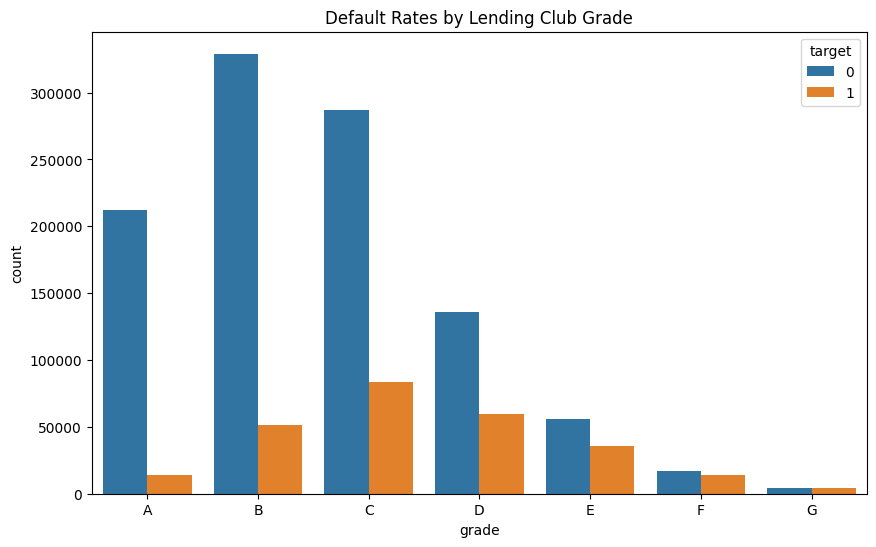

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Correlation with Target
# We only look at numeric columns for now
numeric_df = df_clean.select_dtypes(include=[np.number])
correlations = numeric_df.corr()['target'].sort_values(ascending=False)

print("Top 10 features correlated with Default:")
print(correlations.head(10))

# 2. Visualizing a key Categorical feature: Loan Grade
plt.figure(figsize=(10,6))
sns.countplot(x='grade', data=df_clean, hue='target', order=sorted(df_clean['grade'].unique()))
plt.title('Default Rates by Lending Club Grade')
plt.show()

Phase 4: Data Transformation & Handling "The Mess"
Now we move into the technical "heavy lifting." We have 68 columns, but they aren't ready for a model yet. We need to handle missing values and convert text to numbers.

Step 4: Selective Imputation & Encoding
We won't just use a "blanket" fill. We need to be smart:

Categorical: term, home_ownership, purpose.

Numeric: annual_inc, dti.

Special Case: emp_length. It's a string like "10+ years" but it represents a number.

Run this block to clean the remaining features and prepare the final matrix:

In [14]:
# 1. Handle 'emp_length' - Convert string to numeric
def clean_emp_length(x):
    if pd.isna(x) or x == '< 1 year':
        return 0
    if x == '10+ years':
        return 10
    return int(''.join(filter(str.isdigit, x)))

df_clean['emp_length'] = df_clean['emp_length'].apply(clean_emp_length)

# 2. Fill missing numeric values with Median (more robust to outliers)
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
df_clean[numeric_cols] = df_clean[numeric_cols].fillna(df_clean[numeric_cols].median())

# 3. Simplify Categorical Data
# Let's see how many unique values are in our object columns
qualitative = df_clean.select_dtypes(include=['object']).columns
print("Categorical columns to encode:", qualitative.tolist())

# 4. One-Hot Encoding (Converting text to 1s and 0s)
# Note: We drop 'loan_status' because it IS our target (avoiding circular logic)
df_final = pd.get_dummies(df_clean.drop('loan_status', axis=1), columns=['term', 'grade', 'sub_grade', 'home_ownership', 'verification_status', 'purpose', 'initial_list_status', 'application_type', 'disbursement_method'], drop_first=True)

print(f"\nFinal Shape for Modeling: {df_final.shape}")

Categorical columns to encode: ['term', 'grade', 'sub_grade', 'home_ownership', 'verification_status', 'loan_status', 'purpose', 'earliest_cr_line', 'initial_list_status', 'application_type', 'hardship_flag', 'disbursement_method']

Final Shape for Modeling: (1303638, 122)


Phase 5: Handling Outliers and Scaling (The "Missing Links")
In our previous session, we identified that skipping these steps is a major red flag in an interview. Let's do them properly now.

1. Outlier Detection (The "Z-Score" or "IQR" Method)
In financial data, some people have massive incomes or huge debts that can pull the model's "average" off-center. We typically look at annual_inc and dti.

The Strategy: We won't necessarily delete them (they might be real!), but we can cap them at the 99th percentile so they don't skew the results.

2. Feature Scaling
Since we have features like annual_inc (often 50,000+) and dti (often 15.0), the model might think income is "more important" just because the numbers are bigger.

The Fix: We will use StandardScaler to make sure every feature has a mean of 0 and a standard deviation of 1.

Step 5: Final Pre-Processing Code
Run this block to fix the date feature, handle outliers, and scale the data.

In [15]:
from sklearn.preprocessing import StandardScaler

# 1. Feature Engineering: Convert 'earliest_cr_line' to years of credit history
# We'll extract the year and subtract it from 2019 (the end of the dataset era)
df_final['earliest_cr_year'] = pd.to_numeric(df_clean['earliest_cr_line'].str.split('-').str[-1])
df_final['credit_age_years'] = 2019 - df_final['earliest_cr_year']
df_final.drop(['earliest_cr_year'], axis=1, inplace=True)

# 2. Handling Outliers: Capping at 99th percentile for 'annual_inc'
upper_limit = df_final['annual_inc'].quantile(0.99)
df_final['annual_inc'] = np.where(df_final['annual_inc'] > upper_limit, upper_limit, df_final['annual_inc'])

# 3. Scaling the Numeric Features
# We don't scale the 'target' or the binary (0/1) dummy variables
columns_to_scale = [
    'loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 
    'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'credit_age_years'
]

scaler = StandardScaler()
df_final[columns_to_scale] = scaler.fit_transform(df_final[columns_to_scale])

print("Outliers capped and Scaling complete.")
print("\nSample of scaled annual_inc (should be small numbers now):")
print(df_final['annual_inc'].head())

Outliers capped and Scaling complete.

Sample of scaled annual_inc (should be small numbers now):
100    0.606577
152   -0.701675
170    0.606577
186   -0.856286
215    4.174536
Name: annual_inc, dtype: float64


Phase 6: Train-Test Split & Addressing Class Imbalance
Now we are at the final stage before training. Because we have 2.2 million rows (now 1.3M after filtering), we have to be careful about how we split the data.

1. The Stratified Split
Remember that only 20% of our borrowers defaulted. If we do a random split, there’s a small chance one set gets way more defaults than the other.

The Fix: We use stratify=y. This ensures that both your Training set and your Testing set have exactly 20% defaults.

2. Handling Imbalance (The Interview Strategy)
The interviewer will ask: "How will you handle the fact that you have 4x more 'Good' loans than 'Bad' loans?"

Your Answer: "I have a few options. I can use SMOTE (Oversampling), Undersampling, or simply use a model like XGBoost/Random Forest and adjust the scale_pos_weight or class_weight parameter. Given the large size of this dataset (1.3M rows), adjusting the model weights is usually more efficient than generating synthetic data."

In [16]:
# 1. Define your target (y)
y = df_final['target']

# 2. Define your features (X) 
# We drop 'target' and the original date string 'earliest_cr_line' 
# also 'hardship_flag' if it was not encoded properly
cols_to_drop = ['target', 'earliest_cr_line', 'hardship_flag']
X = df_final.drop(columns=[c for c in cols_to_drop if c in df_final.columns])

# Now run the diagnostics
print(f"Non-numeric columns remaining: {list(X.select_dtypes(exclude=[np.number]).columns)}")
print(f"Total NaN values in X: {X.isnull().sum().sum()}")
print(f"Total Infinite values in X: {np.isinf(X).values.sum()}")
print(f"Final Feature Count: {X.shape[1]}")

Non-numeric columns remaining: ['term_ 60 months', 'grade_B', 'grade_C', 'grade_D', 'grade_E', 'grade_F', 'grade_G', 'sub_grade_A2', 'sub_grade_A3', 'sub_grade_A4', 'sub_grade_A5', 'sub_grade_B1', 'sub_grade_B2', 'sub_grade_B3', 'sub_grade_B4', 'sub_grade_B5', 'sub_grade_C1', 'sub_grade_C2', 'sub_grade_C3', 'sub_grade_C4', 'sub_grade_C5', 'sub_grade_D1', 'sub_grade_D2', 'sub_grade_D3', 'sub_grade_D4', 'sub_grade_D5', 'sub_grade_E1', 'sub_grade_E2', 'sub_grade_E3', 'sub_grade_E4', 'sub_grade_E5', 'sub_grade_F1', 'sub_grade_F2', 'sub_grade_F3', 'sub_grade_F4', 'sub_grade_F5', 'sub_grade_G1', 'sub_grade_G2', 'sub_grade_G3', 'sub_grade_G4', 'sub_grade_G5', 'home_ownership_MORTGAGE', 'home_ownership_NONE', 'home_ownership_OTHER', 'home_ownership_OWN', 'home_ownership_RENT', 'verification_status_Source Verified', 'verification_status_Verified', 'purpose_credit_card', 'purpose_debt_consolidation', 'purpose_educational', 'purpose_home_improvement', 'purpose_house', 'purpose_major_purchase', 'p

In [17]:
# Create correlation matrix
corr_matrix = X.corr().abs()

# Select upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features with correlation greater than 0.90
to_drop = [column for column in upper.columns if any(upper[column] > 0.90)]

print(f"Redundant columns identified (>0.90 correlation): {to_drop}")

# If you want to drop them to simplify the model:
# X = X.drop(columns=to_drop)

Redundant columns identified (>0.90 correlation): ['funded_amnt', 'funded_amnt_inv', 'installment', 'num_rev_tl_bal_gt_0', 'num_sats', 'tot_hi_cred_lim']


In [18]:
# 1. Drop the redundant features identified
redundant_cols = ['funded_amnt', 'funded_amnt_inv', 'installment', 'num_rev_tl_bal_gt_0', 'num_sats', 'tot_hi_cred_lim']
X = X.drop(columns=redundant_cols)

# 2. Ensure all columns are numeric (float32 is memory efficient for 1.3M rows)
X = X.astype('float32')

print(f"Final shape of X before split: {X.shape}")
print(f"Final shape of y: {y.shape}")

Final shape of X before split: (1303638, 114)
Final shape of y: (1303638,)


In [19]:
from sklearn.model_selection import train_test_split

# We split 80% for training and 20% for testing
# random_state ensures we get the same results every time we run it
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training Features: {X_train.shape}")
print(f"Testing Features: {X_test.shape}")
print(f"\nDefault Rate in Training: {y_train.mean():.2%}")
print(f"Default Rate in Testing: {y_test.mean():.2%}")

Training Features: (1042910, 114)
Testing Features: (260728, 114)

Default Rate in Training: 20.07%
Default Rate in Testing: 20.07%


In [20]:
import gc
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 1. Clear Memory: Delete large objects we no longer need
# This is crucial for a dataset of 2.2M rows
try:
    del df
    del df_filtered
    del df_clean
    gc.collect() # Manually trigger garbage collection
    print("Memory cleared successfully.")
except NameError:
    print("Dataframes already deleted.")

# 2. Initialize Logistic Regression
# We use 'liblinear' or 'saga' for large datasets
# We use class_weight='balanced' to handle the 20/80 imbalance
log_model = LogisticRegression(solver='saga', max_iter=500, class_weight='balanced', n_jobs=-1)

# 3. Train the model
print("Training Logistic Regression (Baseline)...")
log_model.fit(X_train, y_train)

# 4. Make Predictions
y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:, 1]

print("\n--- Baseline Model Results ---")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

Memory cleared successfully.
Training Logistic Regression (Baseline)...

--- Baseline Model Results ---
              precision    recall  f1-score   support

           0       0.83      0.58      0.68    208391
           1       0.24      0.53      0.33     52337

    accuracy                           0.57    260728
   macro avg       0.54      0.56      0.51    260728
weighted avg       0.71      0.57      0.61    260728

ROC-AUC Score: 0.5835


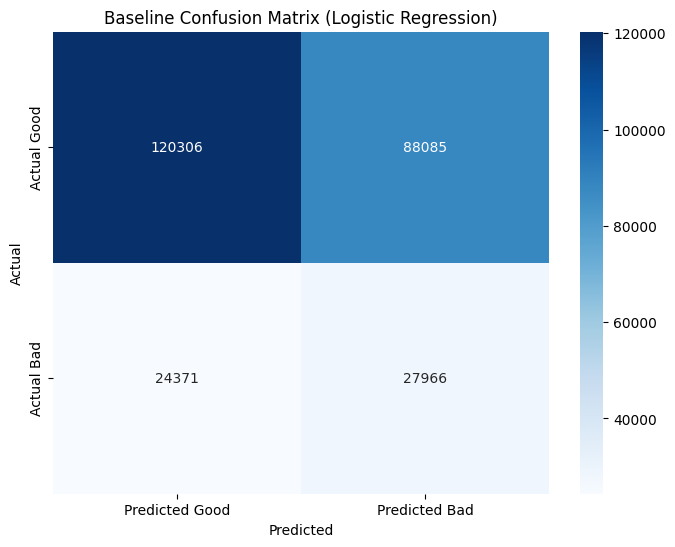

Number of Good borrowers accidentally rejected: 88085


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plotting
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Good', 'Predicted Bad'],
            yticklabels=['Actual Good', 'Actual Bad'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Baseline Confusion Matrix (Logistic Regression)')
plt.show()

# Calculate the "False Positive" cost
false_positives = cm[0][1]
print(f"Number of Good borrowers accidentally rejected: {false_positives}")

Step 8: Training the XGBoost Model
Run this code to see if we can significantly improve our metrics.

In [22]:
!brew install libomp


To reinstall 21.1.8, run:
  brew reinstall libomp


In [23]:
import xgboost as xgb


In [24]:
import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score

# 1. Initialize XGBoost
# scale_pos_weight is roughly the ratio of (Negative Class / Positive Class) 
# In our case, 80/20 = 4. This helps the model focus on the 20% defaults.
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=4,
    use_label_encoder=False,
    eval_metric='logloss',
    n_jobs=-1,
    tree_method='hist' # Faster for large datasets like yours
)

# 2. Train the model
print("Training XGBoost...")
xgb_model.fit(X_train, y_train)

# 3. Predict and Evaluate
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("\n--- XGBoost Model Results ---")
print(classification_report(y_test, y_pred_xgb))
print(f"XGBoost ROC-AUC Score: {roc_auc_score(y_test, y_prob_xgb):.4f}")

Training XGBoost...


/opt/homebrew/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [10:58:57] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- XGBoost Model Results ---
              precision    recall  f1-score   support

           0       0.89      0.65      0.75    208391
           1       0.33      0.68      0.44     52337

    accuracy                           0.65    260728
   macro avg       0.61      0.66      0.59    260728
weighted avg       0.78      0.65      0.69    260728

XGBoost ROC-AUC Score: 0.7260


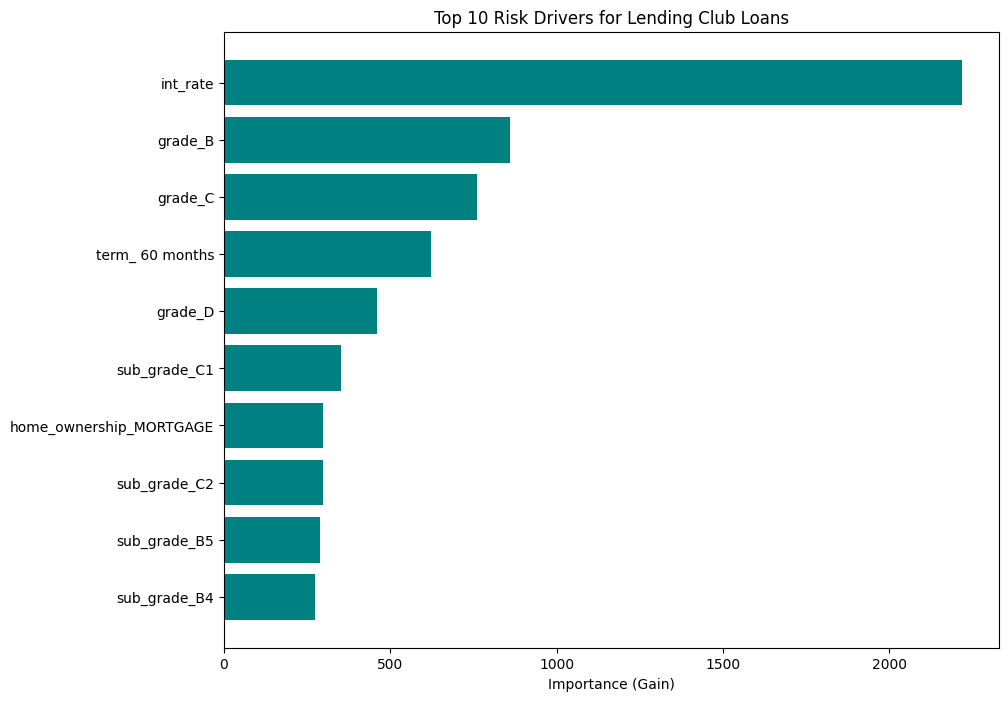

In [25]:
import matplotlib.pyplot as plt

# Get feature importance from XGBoost
importance = xgb_model.get_booster().get_score(importance_type='gain')
importance = sorted(importance.items(), key=lambda x: x[1], reverse=True)

# Map importance back to feature names
top_features = importance[:10]
features, scores = zip(*top_features)

# Plotting
plt.figure(figsize=(10, 8))
plt.barh(features, scores, color='teal')
plt.xlabel('Importance (Gain)')
plt.title('Top 10 Risk Drivers for Lending Club Loans')
plt.gca().invert_yaxis()
plt.show()

In [26]:
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb

# 1. Define the parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'scale_pos_weight': [4] # Keeping our imbalance fix constant
}

# 2. Initialize the search
# n_iter=5 means we test 5 random combinations
# cv=3 means we use 3-fold cross-validation
random_search = RandomizedSearchCV(
    estimator=xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', tree_method='hist'),
    param_distributions=param_grid,
    n_iter=5, 
    scoring='roc_auc',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# 3. Run the search
print("Starting Randomized Search (This may take 5-10 minutes)...")
random_search.fit(X_train, y_train)

# 4. Display results
print(f"\nBest Parameters: {random_search.best_params_}")
print(f"Best ROC-AUC from Cross-Validation: {random_search.best_score_:.4f}")

Starting Randomized Search (This may take 5-10 minutes)...
Fitting 3 folds for each of 5 candidates, totalling 15 fits


/opt/homebrew/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [11:00:03] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/homebrew/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [11:00:03] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/homebrew/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [11:00:03] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/homebrew/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [11:00:03] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fo

[CV] END colsample_bytree=0.9, learning_rate=0.01, max_depth=3, n_estimators=100, scale_pos_weight=4, subsample=0.8; total time=  47.2s
[CV] END colsample_bytree=0.9, learning_rate=0.01, max_depth=3, n_estimators=100, scale_pos_weight=4, subsample=0.8; total time=  48.1s
[CV] END colsample_bytree=0.9, learning_rate=0.01, max_depth=3, n_estimators=100, scale_pos_weight=4, subsample=0.8; total time=  48.5s
[CV] END colsample_bytree=0.9, learning_rate=0.1, max_depth=3, n_estimators=200, scale_pos_weight=4, subsample=0.9; total time= 1.0min
[CV] END colsample_bytree=0.9, learning_rate=0.1, max_depth=3, n_estimators=200, scale_pos_weight=4, subsample=0.9; total time= 1.0min


/opt/homebrew/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [11:00:58] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/homebrew/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [11:00:58] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/homebrew/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [11:00:59] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.9, learning_rate=0.2, max_depth=9, n_estimators=100, scale_pos_weight=4, subsample=0.9; total time= 1.1min
[CV] END colsample_bytree=0.9, learning_rate=0.2, max_depth=9, n_estimators=100, scale_pos_weight=4, subsample=0.9; total time= 1.2min
[CV] END colsample_bytree=0.9, learning_rate=0.2, max_depth=9, n_estimators=100, scale_pos_weight=4, subsample=0.9; total time= 1.2min
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, scale_pos_weight=4, subsample=0.8; total time=  39.4s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, scale_pos_weight=4, subsample=0.8; total time=  39.5s


/opt/homebrew/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [11:01:22] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/homebrew/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [11:01:23] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/homebrew/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [11:01:23] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/homebrew/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [11:01:25] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fo

[CV] END colsample_bytree=0.9, learning_rate=0.1, max_depth=3, n_estimators=200, scale_pos_weight=4, subsample=0.9; total time=  51.8s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, scale_pos_weight=4, subsample=0.8; total time=  45.5s
[CV] END colsample_bytree=0.8, learning_rate=0.2, max_depth=3, n_estimators=200, scale_pos_weight=4, subsample=0.8; total time=  50.5s
[CV] END colsample_bytree=0.8, learning_rate=0.2, max_depth=3, n_estimators=200, scale_pos_weight=4, subsample=0.8; total time=  40.3s
[CV] END colsample_bytree=0.8, learning_rate=0.2, max_depth=3, n_estimators=200, scale_pos_weight=4, subsample=0.8; total time=  40.7s


/opt/homebrew/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [11:01:48] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Best Parameters: {'subsample': 0.8, 'scale_pos_weight': 4, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.2, 'colsample_bytree': 0.8}
Best ROC-AUC from Cross-Validation: 0.7280


In [27]:
# 1. Initialize the Final Model with Best Parameters
final_xgb = xgb.XGBClassifier(
    **random_search.best_params_,
    tree_method='hist',
    eval_metric='logloss',
    n_jobs=-1
)

# 2. Train on the full Training Set
print("Training the Final Champion Model...")
final_xgb.fit(X_train, y_train)

# 3. Final Evaluation
final_pred = final_xgb.predict(X_test)
final_prob = final_xgb.predict_proba(X_test)[:, 1]

print("\n--- FINAL PRODUCTION REPORT ---")
print(classification_report(y_test, final_pred))
print(f"Final Test ROC-AUC Score: {roc_auc_score(y_test, final_prob):.4f}")

Training the Final Champion Model...

--- FINAL PRODUCTION REPORT ---
              precision    recall  f1-score   support

           0       0.89      0.65      0.75    208391
           1       0.33      0.68      0.44     52337

    accuracy                           0.65    260728
   macro avg       0.61      0.66      0.60    260728
weighted avg       0.78      0.65      0.69    260728

Final Test ROC-AUC Score: 0.7269
